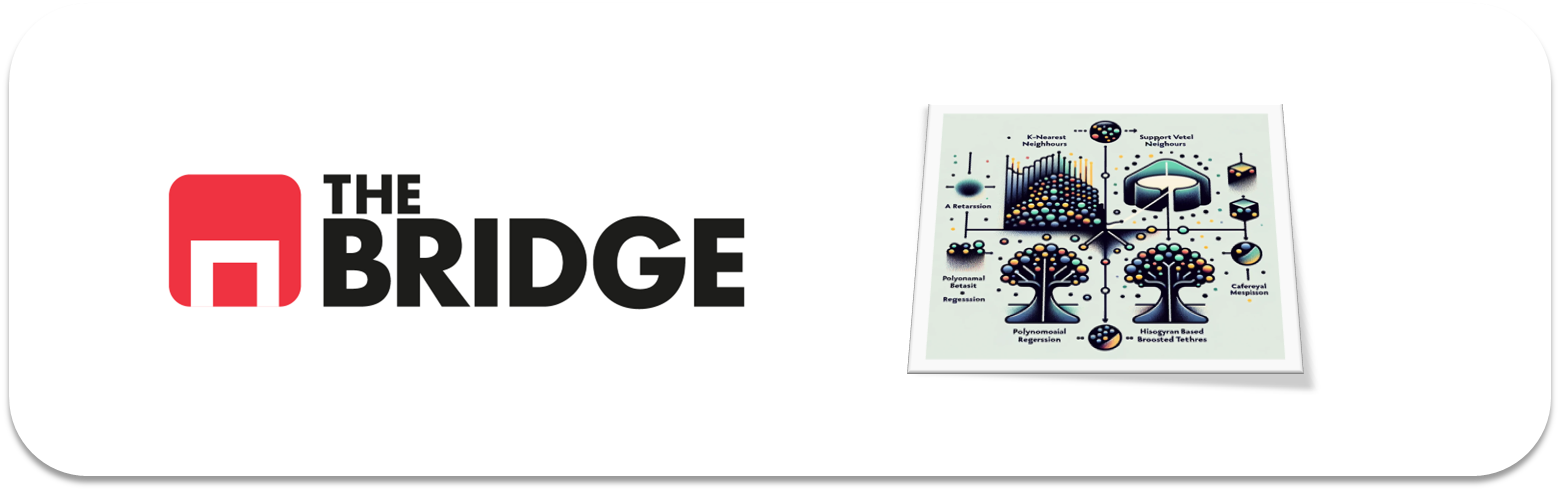

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score,mean_absolute_percentage_error, root_mean_squared_error, r2_score
)

from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [2]:
df = pd.read_csv("./data/wines_dataset.csv", sep="|")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [3]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
fixed acidity,float64,0.0,106,1.63
volatile acidity,float64,0.0,187,2.88
citric acid,float64,0.0,89,1.37
residual sugar,float64,0.0,316,4.86
chlorides,float64,0.0,214,3.29
free sulfur dioxide,float64,0.0,135,2.08
total sulfur dioxide,float64,0.0,276,4.25
density,float64,0.0,998,15.36
pH,float64,0.0,108,1.66
sulphates,float64,0.0,111,1.71


In [4]:
tipifica_variables(df, umbral_categoria=10, umbral_continua=15)

,nombre_variable,tipo_sugerido
0,fixed acidity,Numérica Discreta
1,volatile acidity,Numérica Discreta
2,citric acid,Numérica Discreta
3,residual sugar,Numérica Discreta
4,chlorides,Numérica Discreta
5,free sulfur dioxide,Numérica Discreta
6,total sulfur dioxide,Numérica Discreta
7,density,Numérica Continua
8,pH,Numérica Discreta
9,sulphates,Numérica Discreta


In [5]:
target_c = "quality"
target_r = "alcohol"

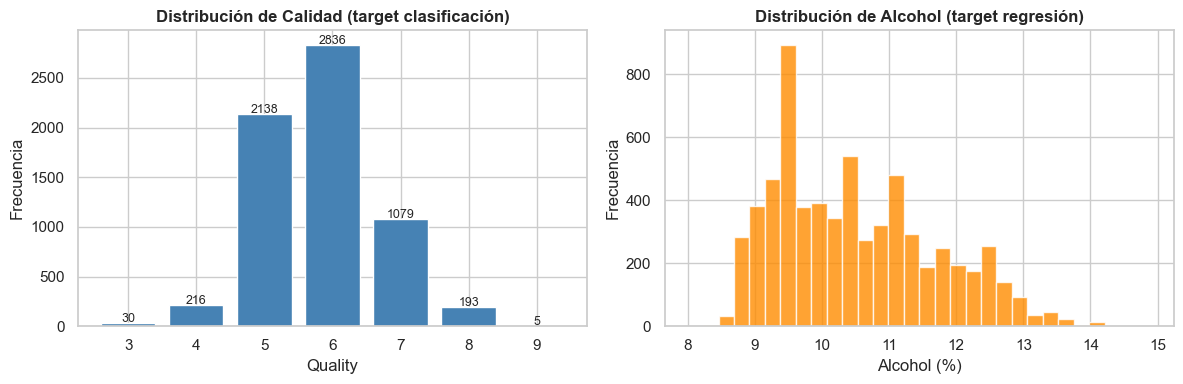


Distribución quality:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Imbalance ratio (clase mayoritaria/minoritaria): 567x

Describe de alcohol: count    6497.000000
mean       10.491801
std         1.192712
min         8.000000
25%         9.500000
50%        10.300000
75%        11.300000
max        14.900000
Name: alcohol, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de quality
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Calidad (target clasificación)', fontweight='bold')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Frecuencia')
for i, (k, v) in enumerate(quality_counts.items()):
    axes[0].text(k, v + 10, str(v), ha='center', fontsize=9)

# Distribución de alcohol
axes[1].hist(df['alcohol'], bins=30, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución de Alcohol (target regresión)', fontweight='bold')
axes[1].set_xlabel('Alcohol (%)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('\nDistribución quality:')
print(quality_counts)
print(f'\nImbalance ratio (clase mayoritaria/minoritaria): {quality_counts.max()/quality_counts.min():.0f}x')
print('\nDescribe de alcohol:', df['alcohol'].describe())

## Conclusión: Variable objetivo *Quality* (Clasificación)

La variable **Quality** presenta un fuerte desbalance de clases, concentrándose principalmente en las categorías **5** y **6**, que representan más del **76 %** de todas las observaciones. Por el contrario, las clases extremas (**3** y **9**) apenas están representadas, alcanzando un ratio de desbalance de **567:1** entre la clase mayoritaria y la minoritaria.

Esta distribución supone un desafío para los modelos de clasificación, ya que tienden a favorecer las clases más frecuentes. Por ello, resulta necesario utilizar métricas robustas frente al desbalance, como **Recall Macro**, **Precision Macro** y **F1 Macro**, que permiten evaluar el rendimiento de forma equilibrada en todas las categorías de calidad.

## Conclusión: Variable objetivo *Alcohol (%)* (Regresión)

La variable **Alcohol (%)** presenta una distribución continua centrada en torno al **10,5 %**, con una media de **10,49 %** y una mediana de **10,30 %**. La ligera diferencia entre ambas medidas indica una leve asimetría positiva, provocada por la presencia de algunos vinos con graduaciones alcohólicas más elevadas.

La dispersión es moderada (desviación estándar de **1,19 %**) y el 50 % de los vinos se encuentra entre **9,5 %** y **11,3 %** de alcohol. En general, la variable muestra una distribución estable y bien representada en todo su rango de valores.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

### Separación de train y test

In [7]:
X = df.drop(columns=target_c)
y = df[target_c]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nDistribución del target en train: {y_train.value_counts(normalize=True)}")
print(f"\nDistribución del target en test: {y_test.value_counts(normalize=True)}")

Train: (5197, 12) | Test: (1300, 12)

Distribución del target en train: quality
6    0.436598
5    0.329036
7    0.166057
4    0.033288
8    0.029632
3    0.004618
9    0.000770
Name: proportion, dtype: float64

Distribución del target en test: quality
6    0.436154
5    0.329231
7    0.166154
4    0.033077
8    0.030000
3    0.004615
9    0.000769
Name: proportion, dtype: float64


### Analisis de variables numéricas y su realción con el target

In [8]:
X_train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,5197.000000,5197.000000,5197.000000,5197.000000,5197.000000,5197.000000,5197.000000,5197.000000,5197.000000,5197.000000,5197.000000
mean,7.225159,0.338890,0.317801,5.458187,0.055968,30.649413,116.021840,0.994732,3.217982,0.531459,10.478466
std,1.305226,0.162974,0.145208,4.794210,0.033980,17.896279,56.642512,0.003006,0.159441,0.147496,1.185101
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.740000,0.220000,8.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,17.000000,77.000000,0.992400,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994940,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.997000,3.320000,0.600000,11.300000
max,15.900000,1.330000,1.660000,65.800000,0.467000,289.000000,440.000000,1.038980,4.010000,1.980000,14.900000


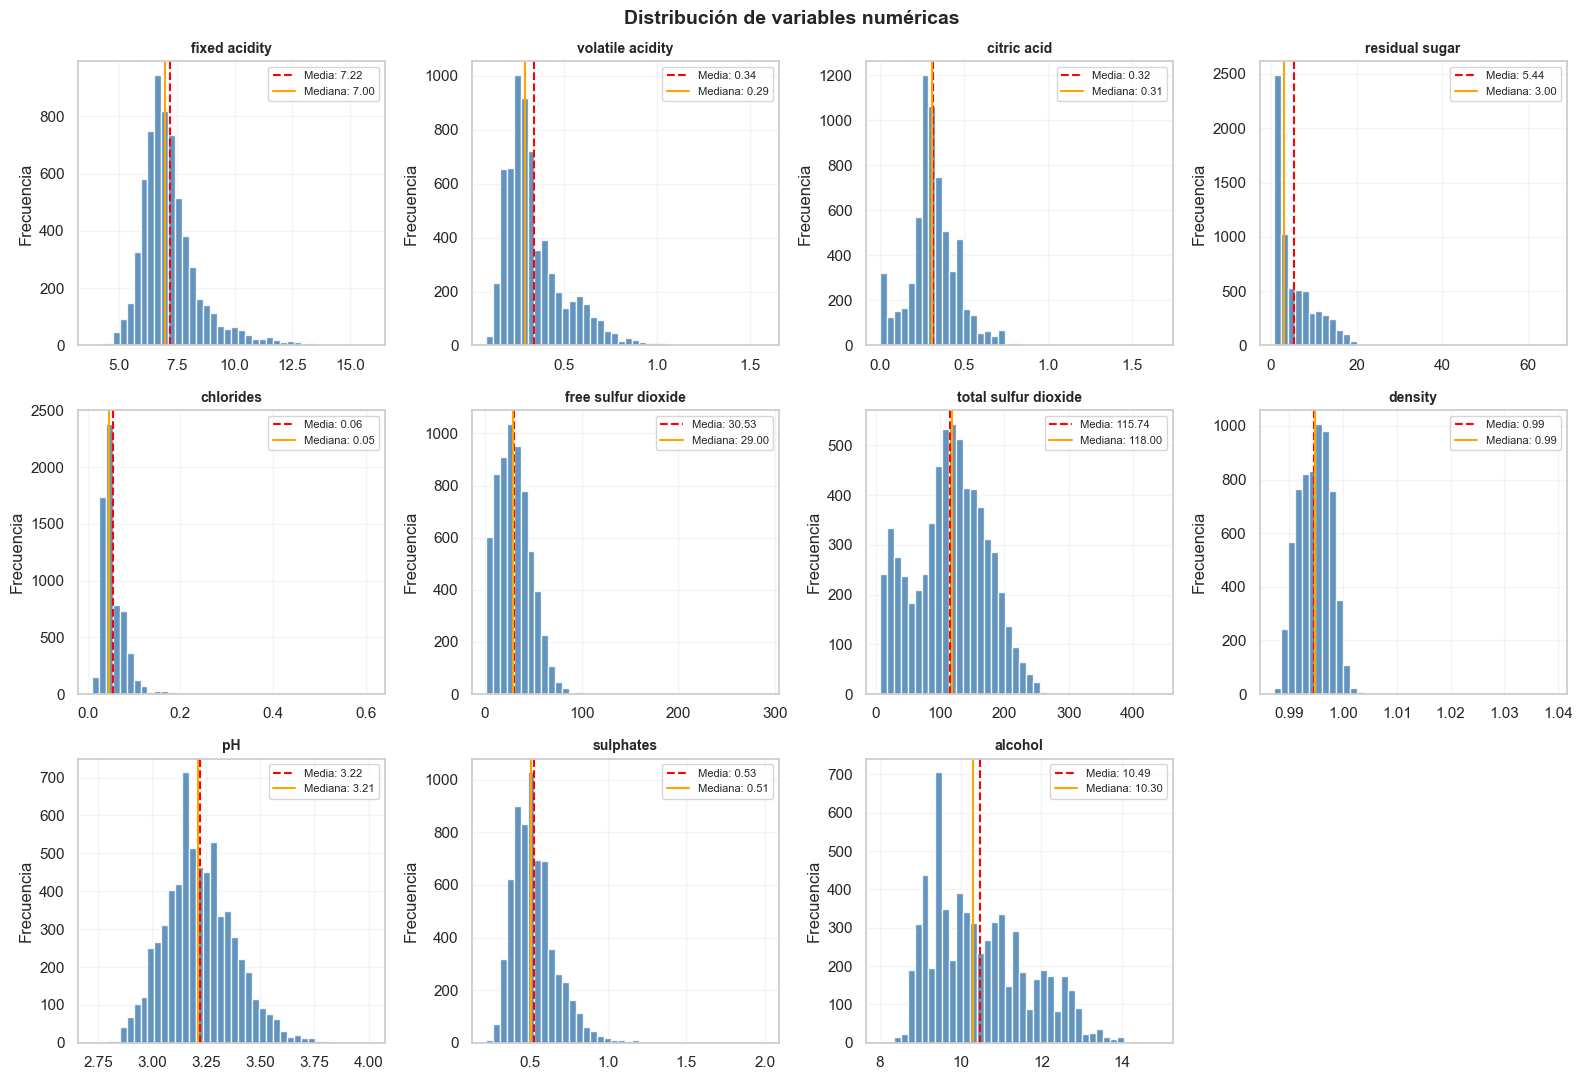

In [9]:
cols_numericas = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                  'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                  'pH', 'sulphates', 'alcohol']

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Distribución de variables numéricas', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(cols_numericas):
    axes[i].hist(df[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df[feat].mean(), color='red', linewidth=1.5, linestyle='--',
                    label=f'Media: {df[feat].mean():.2f}')
    axes[i].axvline(df[feat].median(), color='orange', linewidth=1.5, linestyle='-',
                    label=f'Mediana: {df[feat].median():.2f}')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.2)

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

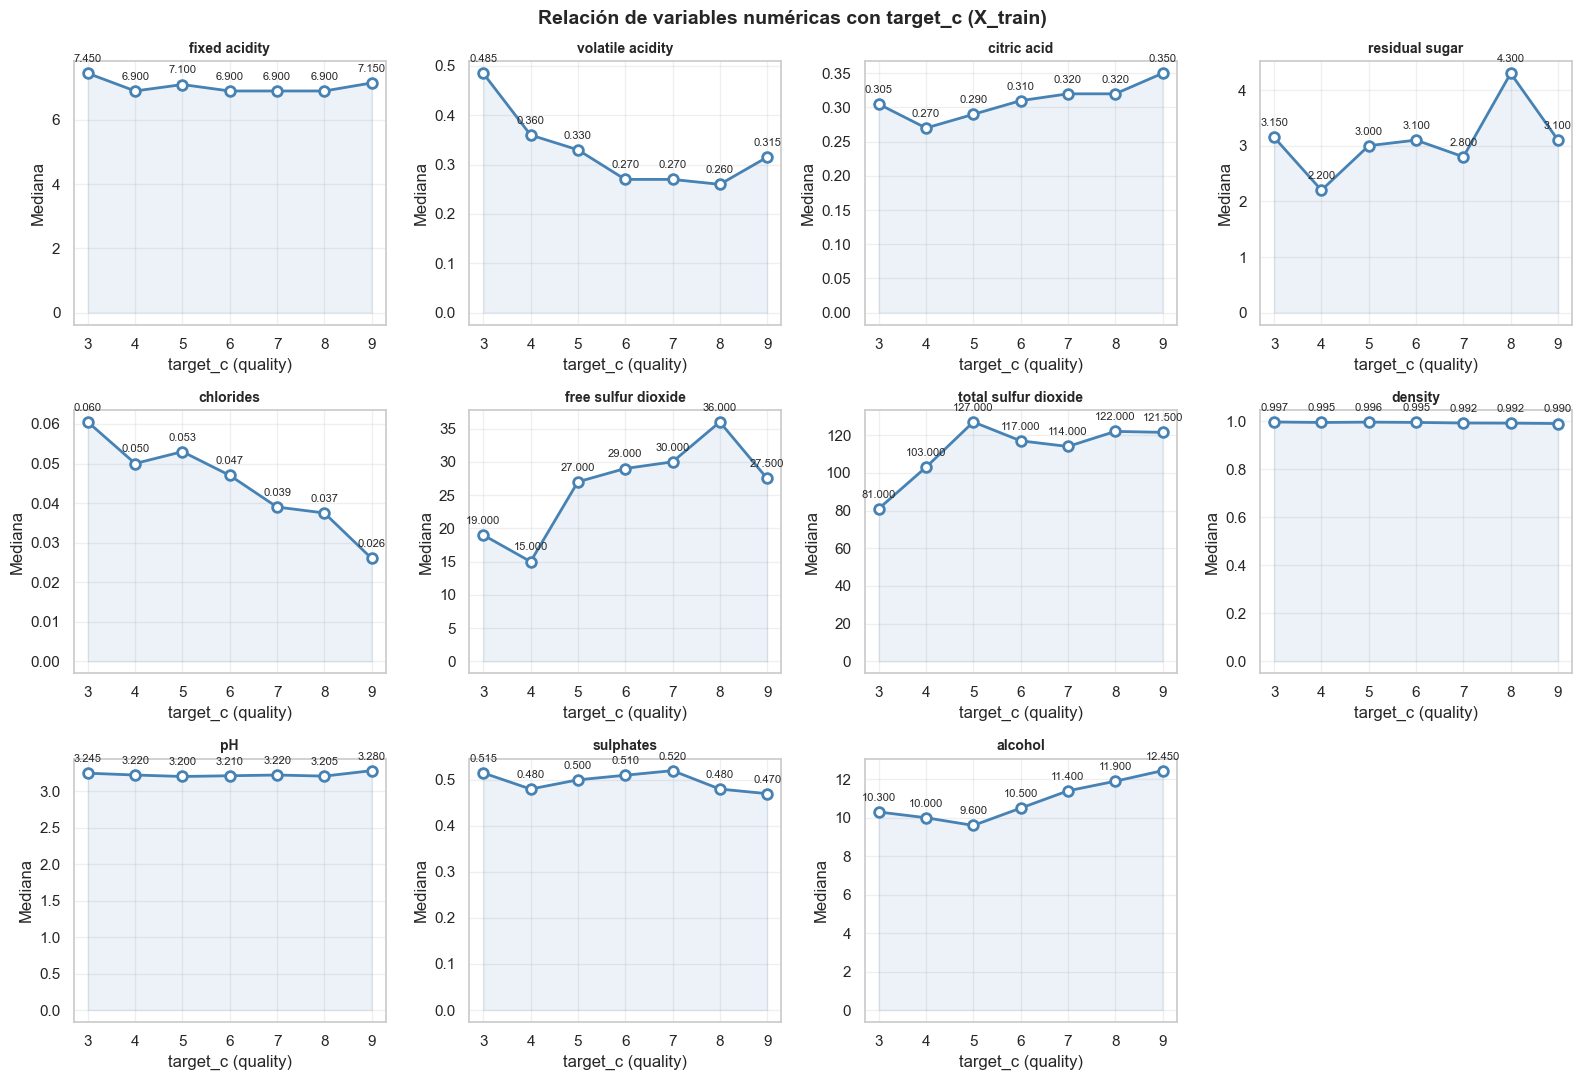

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Relación de variables numéricas con target_c (X_train)', fontsize=14, fontweight='bold')
axes = axes.flatten()

train_df = X_train.copy()
train_df['target_c'] = y_train.values

for i, feat in enumerate(cols_numericas):
    medians = train_df.groupby('target_c')[feat].median()
    axes[i].plot(medians.index, medians.values, marker='o', linewidth=2,
                 color='steelblue', markersize=7, markerfacecolor='white',
                 markeredgewidth=2)
    axes[i].fill_between(medians.index, medians.values, alpha=0.1, color='steelblue')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('target_c (quality)')
    axes[i].set_ylabel('Mediana')
    axes[i].set_xticks(medians.index)
    axes[i].grid(True, alpha=0.3)
    for x, y in zip(medians.index, medians.values):
        axes[i].annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                         xytext=(0, 8), ha='center', fontsize=8)

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Viendo esto gráficos vemos una distribución muy plana entre clases de ph y density, vamos a medir correlaciones antes de decidir con que features quedarnos

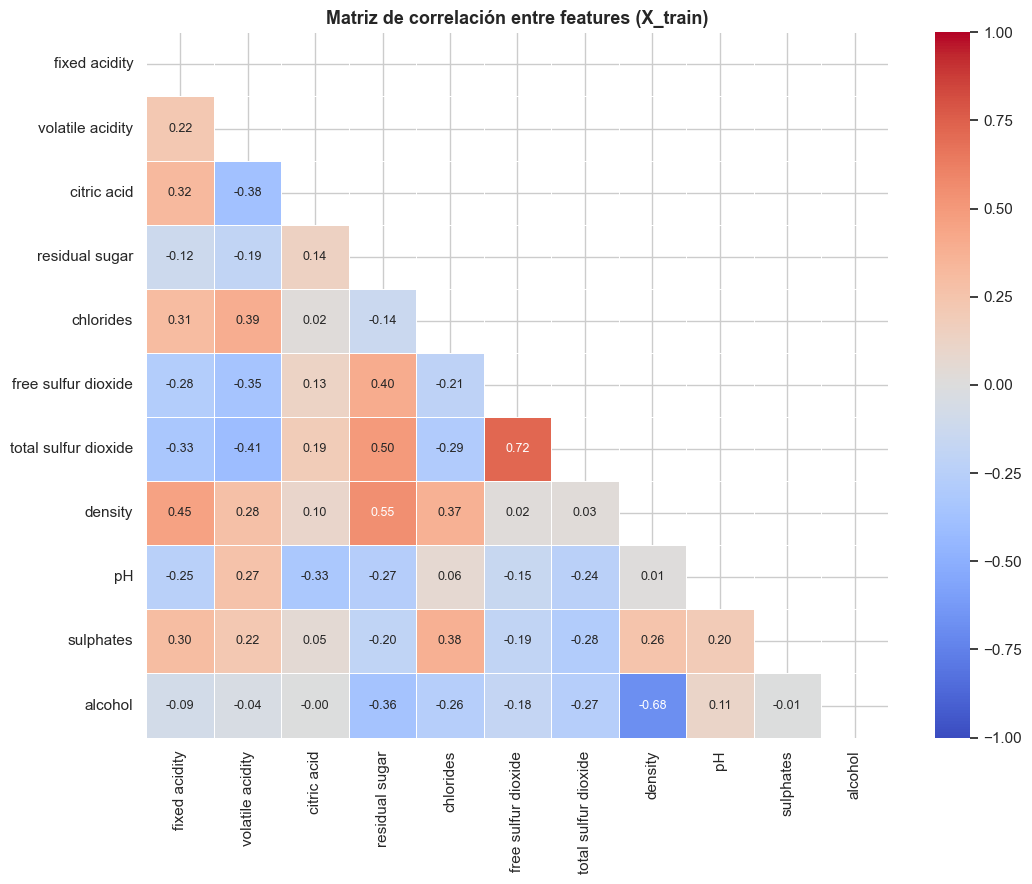

In [11]:
corr_matrix = X_train[cols_numericas].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Matriz de correlación entre features (X_train)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

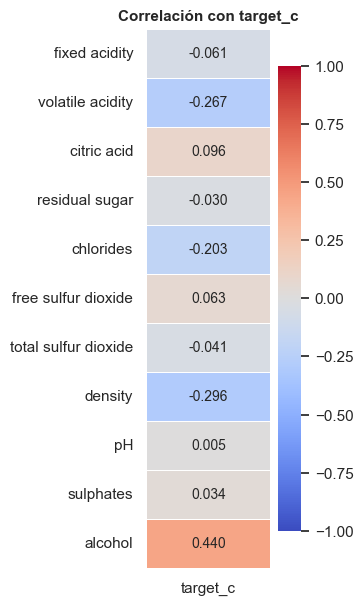

In [12]:
corr_target = X_train[cols_numericas].corrwith(y_train).to_frame(name='target_c')

fig, ax = plt.subplots(figsize=(2, 7))
sns.heatmap(corr_target, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Correlación con target_c', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## Análisis de correlaciones

### Correlación con target_c
- Las variables con **menor señal individual** con el target son:
  - `pH` (0.005)
  - `residual sugar` (-0.030)
  - `sulphates` (0.034)
  - `total sulfur dioxide` (-0.041)
  - `free sulfur dioxide` (0.063)

### Correlación entre features
- `free sulfur dioxide` y `total sulfur dioxide` tienen una correlación de **0.72** → muy redundantes, conviene quedarse con una.
- `density` correlaciona fuertemente con `residual sugar` (0.55) y con `alcohol` (-0.68) → información muy solapada.

### Candidatas a eliminar
- `density` → casi plana vs target (-0.296) y muy correlacionada con `alcohol` y `residual sugar`.
- `total sulfur dioxide` → baja señal con target y redundante con `free sulfur dioxide` (0.72).
- `pH` → correlación con target prácticamente cero (0.005).
- `residual sugar` → baja señal con target (-0.030).

### Decisión
Eliminar de forma conservadora `density` y `total sulfur dioxide` y validar con CV
que el recall macro no empeora antes de descartar más variables.

In [13]:
num_selected = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'pH', 'sulphates', 'alcohol']

### Análisis de variables categóricas y su relación con el target

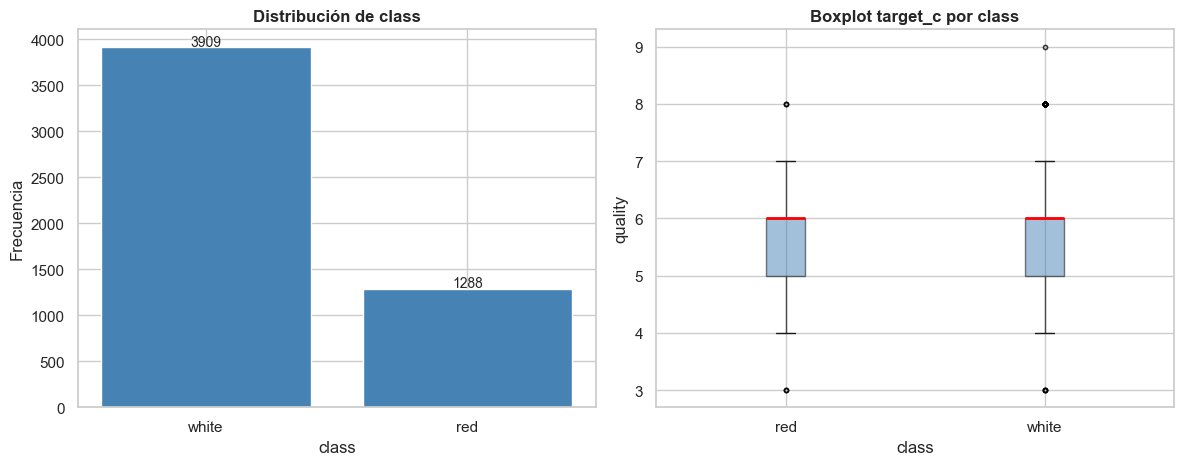

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Relación de 'class' con target_c (X_train)", fontsize=13, fontweight='bold')

train_df = X_train.copy()
train_df['target_c'] = y_train.values

# Distribución de class
class_counts = train_df['class'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de class', fontweight='bold')
axes[0].set_xlabel('class')
axes[0].set_ylabel('Frecuencia')
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Boxplot de target_c por class
train_df.boxplot(column='target_c', by='class', ax=axes[1],
                 patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.5),
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_title('Boxplot target_c por class', fontweight='bold')
axes[1].set_xlabel('class')
axes[1].set_ylabel('quality')
plt.suptitle('')

plt.tight_layout()
plt.show()

Vemos que class no aporta información relevante para predecir la calidad → la descartamos y no la incluimos como feature.

### Selección de features

In [15]:
features = num_selected

X_train_features = X_train[features]
X_test_features = X_test[features]

## Tratamiento de features

In [16]:
# Pasamos a medir la asimetría para tratar aquellas variables que lo necesiten
cols_numericas = [c for c in num_selected if c != 'MonthlyIncome']
print("\n" + "=" * 60)
print("ASIMETRÍA (|skew| > 1 → distribución muy asimétrica)")
print("=" * 60)
skew = X_train[cols_numericas].skew().sort_values(ascending=False)
print(skew.round(3).to_string())
high_skew = skew[abs(skew) > 1].index.tolist()
print(f"\nFeatures con |skew| > 1: {high_skew}")


ASIMETRÍA (|skew| > 1 → distribución muy asimétrica)
chlorides              4.806
fixed acidity          1.759
sulphates              1.754
residual sugar         1.495
volatile acidity       1.455
free sulfur dioxide    1.341
alcohol                0.564
citric acid            0.484
pH                     0.362

Features con |skew| > 1: ['chlorides', 'fixed acidity', 'sulphates', 'residual sugar', 'volatile acidity', 'free sulfur dioxide']


In [17]:
# Version de X_train y X_test para KNN/Linear, para proceder a corregir asimetría y escalar variables numéricas
X_train_lin = X_train_features.copy()
X_test_lin  = X_test_features.copy()

print(type(X_train_lin))
print(X_train_lin.shape)

<class 'pandas.core.frame.DataFrame'>
(5197, 9)


In [18]:
# variables numéricas selecionadas para corregir asimetría
cols_log = [
    'chlorides',
    'fixed acidity',
    'sulphates',
    'residual sugar',
    'volatile acidity',
    'free sulfur dioxide'
]

for col in cols_log:
    X_train_lin[col] = np.log1p(X_train_lin[col])
    X_test_lin[col] = np.log1p(X_test_lin[col])

In [19]:
# Por último escalado de numéricas
scaler = StandardScaler()

X_train_lin[num_selected] = scaler.fit_transform(X_train_lin[cols_numericas])
X_test_lin[num_selected] = scaler.transform(X_test_lin[cols_numericas])

# Verificación
print("Media tras escalado (debe ser ~0):")
print(X_train_lin[cols_numericas].mean().round(4))
print("\nDesviación típica tras escalado (debe ser ~1):")
print(X_train_lin[cols_numericas].std().round(4))

Media tras escalado (debe ser ~0):
fixed acidity          0.0
volatile acidity       0.0
citric acid           -0.0
residual sugar        -0.0
chlorides              0.0
free sulfur dioxide    0.0
pH                     0.0
sulphates             -0.0
alcohol                0.0
dtype: float64

Desviación típica tras escalado (debe ser ~1):
fixed acidity          1.0001
volatile acidity       1.0001
citric acid            1.0001
residual sugar         1.0001
chlorides              1.0001
free sulfur dioxide    1.0001
pH                     1.0001
sulphates              1.0001
alcohol                1.0001
dtype: float64


In [20]:
# Voy a hacer un LabelEncoder con y_train e y_test para que las clase empiecen en 0, sino me dará problemas con algún modelo

le = LabelEncoder()

y_train_en = le.fit_transform(y_train)
y_test_en = le.transform(y_test)

### Selección de modelo

In [23]:
modelos = {
    'Logistic Regression':(LogisticRegression(max_iter=10000, class_weight='balanced'),                                         X_train_lin),
    'Random Forest':      (RandomForestClassifier(max_depth=5, random_state=42, class_weight='balanced'),                       X_train_features),
    'LgbmBoost':          (LGBMClassifier(max_depth=5, random_state=42, verbose=-1, class_weight='balanced', n_jobs=-1 ),       X_train_features),
    'CatBoost':           (CatBoostClassifier(depth=5, random_state=42, verbose=0, auto_class_weights='Balanced'),              X_train_features)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}
for nombre, (modelo, X_cv) in modelos.items():
    scores = cross_validate(
        modelo, X_cv, y_train,
        cv=cv,
        scoring=['recall_macro', 'f1_macro'],
        n_jobs=-1
    )
    resultados[nombre] = {
        'recall_macro':     round(scores['test_recall_macro'].mean(), 4),
        'recall_macro_std': round(scores['test_recall_macro'].std(), 4),
        'f1_macro':         round(scores['test_f1_macro'].mean(), 4),
    }

df_resultados = pd.DataFrame(resultados).T.sort_values('recall_macro', ascending=False)
df_resultados

,recall_macro,recall_macro_std,f1_macro
LgbmBoost,0.3680,0.0106,0.3459
CatBoost,0.3620,0.0078,0.3419
Logistic Regression,0.3480,0.0725,0.1965
Random Forest,0.3459,0.0242,0.2444


## Selección de modelo

### Resultados validación cruzada (5-fold, StratifiedKFold)

| Modelo              | Recall Macro     | F1 Macro |
|---------------------|------------------|----------|
| LightGBM            | 0.368 ± 0.011    | 0.346    |
| CatBoost            | 0.362 ± 0.008    | 0.342    |
| Logistic Regression | 0.348 ± 0.073    | 0.197    |
| Random Forest       | 0.346 ± 0.024    | 0.244    |

### Conclusión

**Modelo seleccionado: LightGBM**

- Obtiene el **mejor Recall Macro (0.368)**, que es nuestra métrica principal de negocio.
- Es el modelo más **estable** junto a CatBoost (±0.011), lo que indica buena capacidad de generalización.
- **Logistic Regression** queda descartada: alta varianza (±0.073) y F1 muy bajo (0.197) → el problema no tiene una frontera de decisión lineal.
- **Random Forest** tiene el peor recall macro (0.346) a pesar de usar `class_weight='balanced'`.
- **CatBoost** es competitivo (0.362) pero queda ligeramente por debajo de LightGBM.

### Siguiente paso
Optimización de hiperparámetros de LightGBM con el objetivo de maximizar el Recall Macro.

### Optimización de parametros

In [27]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'num_leaves':       [31, 50, 70],
    "min_data_in_leaf": [1, 10, 20, 100],
}

lgbm_base = LGBMClassifier(random_state=42, varbose=-1, class_weight='balanced', n_jobs=-1)

grid_search = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid,
    scoring='recall_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1

)

grid_search.fit(X_train_features, y_train)

print(f"Mejores parametros: {grid_search.best_params_}")
print(f"Mejor Recall Macro CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Warning] Unknown parameter: varbose
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: varbose
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000359 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1014
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 9
[LightGBM] [Info] Start training from score -1,945910
[LightGBM] [Info] Start training from score -1,945910
[LightGBM] [Info] Start training from score -1,945910
[LightGBM] [Info] Start training from score -1,945910
[LightGBM] [I

In [29]:
# Entrenar modelo optimizado con los mejores parámetros
best_model = grid_search.best_estimator_


# Predicción en test
y_pred = best_model.predict(X_test_features)

print(classification_report(y_test, y_pred))

[LightGBM] [Warning] Unknown parameter: varbose
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.18      0.44      0.26        43
           5       0.62      0.64      0.63       428
           6       0.62      0.40      0.49       567
           7       0.41      0.54      0.47       216
           8       0.18      0.44      0.25        39
           9       0.00      0.00      0.00         1

    accuracy                           0.50      1300
   macro avg       0.29      0.35      0.30      1300
weighted avg       0.55      0.50      0.51      1300



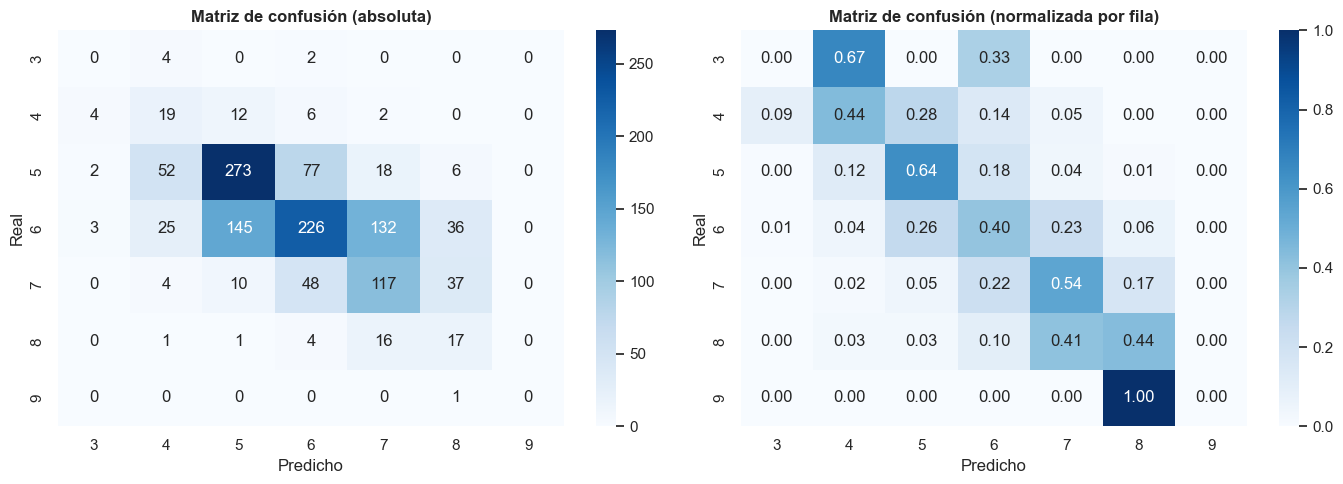

In [30]:
# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matriz de confusión (absoluta)', fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Matriz de confusión (normalizada por fila)', fontweight='bold')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

## Evaluación del modelo final – LightGBM optimizado

### Resultados en test

| Métrica        | Valor |
|----------------|-------|
| Recall Macro   | 0.35  |
| F1 Macro       | 0.30  |
| Accuracy       | 0.50  |

### Análisis por clase

| Clase | Recall | Observaciones |
|-------|--------|---------------|
| 3     | 0.00   | Solo 6 muestras en test, se predice como clase 4 y 6 |
| 4     | 0.44   | Se dispersa hacia clases 5 (0.28) y 6 (0.14) |
| 5     | 0.64   | Mejor clase con volumen significativo de muestras |
| 6     | 0.40   | Se dispersa hacia 5 (0.26) y 7 (0.23) |
| 7     | 0.54   | Resultado razonable |
| 8     | 0.44   | Se confunde con clase 7 (0.41) |
| 9     | 0.00   | Solo 1 muestra en test, se predice como clase 8 |

### Conclusiones

- Los errores son casi todos de **clases adyacentes (±1)**.
- El modelo tiende a **desplazar las predicciones hacia el centro** (clases 5, 6, 7) que son las más frecuentes.
- Las **clases extremas (3 y 9) son inaprendibles** con el volumen de muestras disponible.
- La **clase 6** es el principal problema: siendo la mayoritaria, el modelo la confunde con las clases vecinas.
- La bajada de CV (0.386) a test (0.35) indica **cierto overfitting**.


# #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

### Separación de target

In [21]:
X = df.drop(columns=target_r)
y = df[target_r]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape} |  Test: {X_test.shape}")

Train: (5197, 12) |  Test: (1300, 12)


### Relación del target con las variables numéricas

In [22]:
cols_numericas = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                  'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                  'pH', 'sulphates', 'alcohol']
cols_numericas_r =[c for c in cols_numericas if c != 'alcohol']

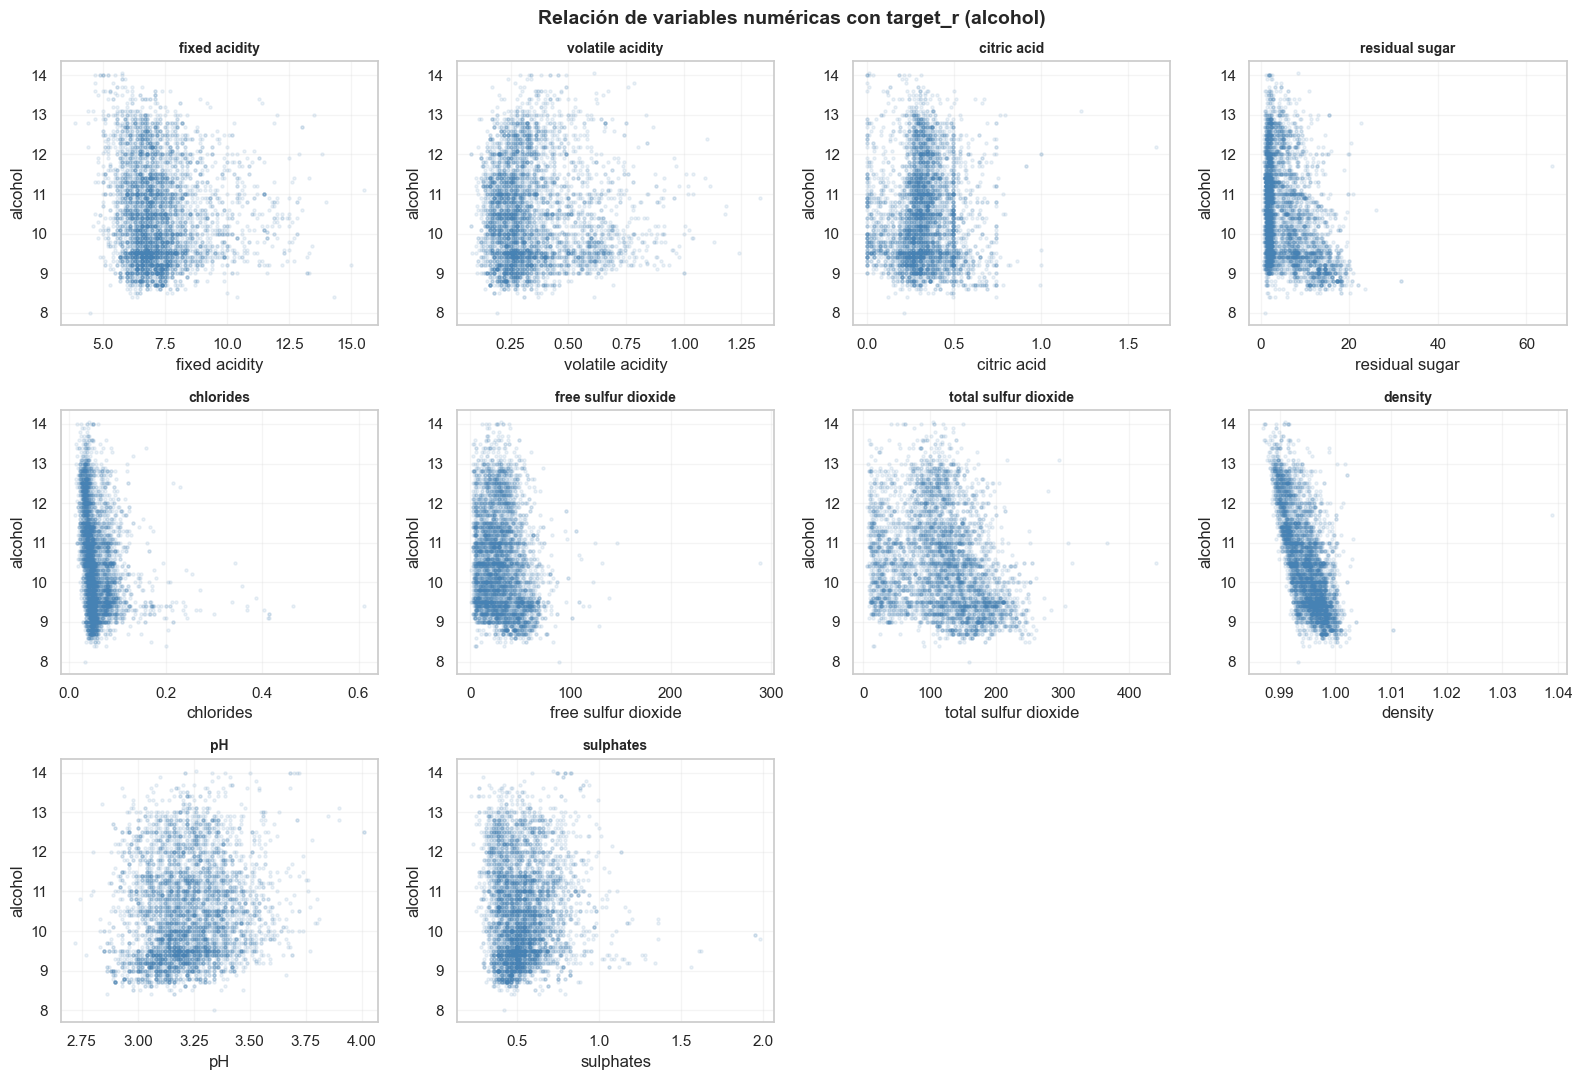

In [23]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Relación de variables numéricas con target_r (alcohol)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(cols_numericas_r):
    axes[i].scatter(X_train[feat], y_train, alpha=0.1, color='steelblue', s=5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('alcohol')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].grid(True, alpha=0.2)

axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
corr_target_r = X_train[cols_numericas_r].corrwith(y_train)
corr_target_r = corr_target_r.reindex(corr_target_r.abs().sort_values(ascending=False).index)

print(corr_target_r.round(3))

density                -0.682
residual sugar         -0.357
total sulfur dioxide   -0.273
chlorides              -0.261
free sulfur dioxide    -0.188
pH                      0.116
fixed acidity          -0.092
volatile acidity       -0.036
citric acid            -0.006
sulphates               0.000
dtype: float64


### Relación del target con las variables categóricas

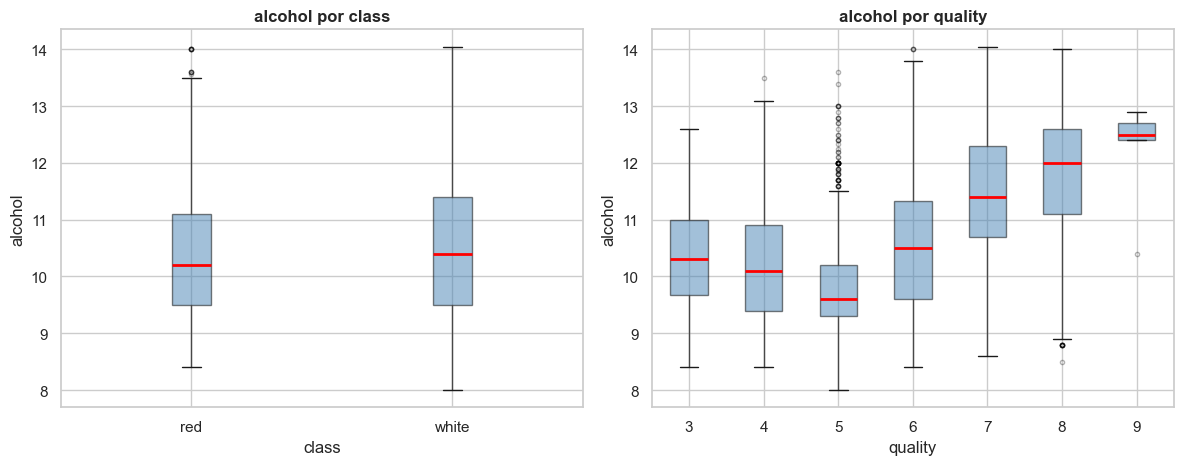

In [25]:
train_df_r = X_train.copy()
train_df_r['alcohol'] = y_train.values


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Relación de 'class' y 'quality' con target_r (alcohol)", fontsize=13, fontweight='bold')

# Boxplot alcohol por class
train_df_r.boxplot(column='alcohol' , by='class', ax=axes[0],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0].set_title('alcohol por class', fontweight='bold')
axes[0].set_xlabel('class')
axes[0].set_ylabel('alcohol')
plt.suptitle('')

# Boxplot alcohol por quality
train_df_r.boxplot(column='alcohol', by='quality', ax=axes[1],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_title('alcohol por quality', fontweight='bold')
axes[1].set_xlabel('quality')
axes[1].set_ylabel('alcohol')
plt.suptitle('')

plt.tight_layout()
plt.show()

## Selección de features – Regresión (target: alcohol)

### Correlación con el target

| Feature              | Correlación |
|----------------------|-------------|
| density              | -0.682      |
| residual sugar       | -0.357      |
| total sulfur dioxide | -0.273      |
| chlorides            | -0.261      |
| free sulfur dioxide  | -0.188      |
| pH                   |  0.116      |
| fixed acidity        | -0.092      |
| volatile acidity     | -0.036      |
| citric acid          | -0.006      |
| sulphates            |  0.000      |

### Conclusiones

**Features seleccionadas: todas las numéricas + quality**

- `density` es el predictor dominante (r = -0.682) con una relación casi lineal y limpia → imprescindible.
- `residual sugar` (r = -0.357) tiene señal relevante y relación física clara con el alcohol (la fermentación convierte azúcar en alcohol).
- `total sulfur dioxide` (r = -0.273) y `chlorides` (r = -0.261) aportan señal moderada.
- `quality` muestra una tendencia ascendente clara con el alcohol (mediana sube de 9.6 en quality 5 a 12.5 en quality 9) → se incluye.
- `citric acid`, `volatile acidity` y `sulphates` tienen correlación prácticamente nula, pero se mantienen por si aportan en interacciones no lineales dentro de los modelos de árboles.
- `class` tiene medianas casi idénticas entre red y white → se **excluye** por no aportar señal relevante.

### Features finales
```python
features_r = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
               'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
               'pH', 'sulphates', 'quality']
```

In [26]:
features_r = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
               'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
               'pH', 'sulphates', 'quality']

### Transformaciones de las features

In [27]:
# Estas son las variables numéricas con asimetría calculadas en el ejercicio anterio
cols_log = [
    'chlorides',
    'fixed acidity',
    'sulphates',
    'residual sugar',
    'volatile acidity',
    'free sulfur dioxide'
]

# Cogemos de las anteriores las que correspondas
cols_log_r  = [f for f in cols_log if f in features_r]
cols_num_r = [f for f in features_r if f != 'quality']


In [28]:
# Para Ridge creo X_train_lin_r y X_test_lin_r 
X_train_lin_r = X_train[features_r].copy()
X_test_lin_r  = X_test[features_r].copy()

# Normalizamos en train y test
X_train_lin_r[cols_log_r] = np.log1p(X_train_lin_r[cols_log_r])
X_test_lin_r[cols_log_r]  = np.log1p(X_test_lin_r[cols_log_r])

# Por último escalamos
scaler_r = StandardScaler()
X_train_lin_r[cols_num_r] = scaler_r.fit_transform(X_train_lin_r[cols_num_r])
X_test_lin_r[cols_num_r]  = scaler_r.transform(X_test_lin_r[cols_num_r])

# Establezco un X_train y X_test para los arboles
X_train_features_r = X_train[features_r].copy()
X_test_features_r  = X_test[features_r].copy()

### Elección del Modelo

In [30]:
modelos_r = {
    'Ridge':         (Ridge(),                                                             X_train_lin_r),
    'Random Forest': (RandomForestRegressor(max_depth=5, random_state=42),                 X_train_features_r),
    'XGBoost':       (XGBRegressor(max_depth=5, random_state=42),                          X_train_features_r),
    'CatBoost':      (CatBoostRegressor(depth=5, random_state=42, verbose=0),              X_train_features_r)
}

resultados_r = {}

for nombre, (modelo, X_cv) in modelos_r.items():
    scores = cross_validate(
        modelo, X_cv, y_train,
        cv=5,
        scoring=['neg_mean_absolute_percentage_error' , 'neg_root_mean_squared_error']
    )
    resultados_r[nombre] = {
        'mape':     round(-scores['test_neg_mean_absolute_percentage_error'].mean(), 4),
        'mape_std': round(scores['test_neg_mean_absolute_percentage_error'].std(), 4),
        'rmse':     round(-scores['test_neg_root_mean_squared_error'].mean(), 4)
    }

df_resultados_r = pd.DataFrame(resultados_r).T.sort_values('mape')
df_resultados_r

,mape,mape_std,rmse
CatBoost,0.0264,0.0008,0.3802
XGBoost,0.0273,0.0008,0.4071
Ridge,0.0405,0.0011,0.6050
Random Forest,0.0451,0.0009,0.6147


## Selección de modelo – Regresión (target: alcohol)

### Resultados validación cruzada (5-fold)

| Modelo        | MAPE             | RMSE  |
|---------------|------------------|-------|
| CatBoost      | 0.0264 ± 0.0008  | 0.380 |
| XGBoost       | 0.0273 ± 0.0008  | 0.407 |
| Ridge         | 0.0405 ± 0.0011  | 0.605 |
| Random Forest | 0.0451 ± 0.0009  | 0.615 |

### Conclusiones

**Modelo seleccionado: CatBoost**

- Obtiene el **mejor MAPE (2.64%)**, que es nuestra métrica principal de negocio: se equivoca solo un 2.64% sobre el grado alcohólico real.
- Es el modelo más **estable** entre folds (±0.08%), lo que indica buena capacidad de generalización.
- **XGBoost** es muy competitivo (2.73%) pero queda ligeramente por debajo de CatBoost.
- **Ridge** obtiene un MAPE del 4.05% → la relación no es puramente lineal, aunque `density` aporta suficiente señal lineal para un resultado razonable.
- **Random Forest** es el peor con 4.51% → con `max_depth=5` está demasiado limitado para capturar la complejidad del problema.

### Siguiente paso
Optimización de hiperparámetros de CatBoost para minimizar el MAPE.

### Optimización de hiperparametros

In [36]:
cat_base_r = CatBoostRegressor(random_state=42, verbose=0)

param_grid = {
    'depth':             [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [100, 200 , 300] 
}

grid_search_r = GridSearchCV(
    estimator=cat_base_r,
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',
    cv=5
)

grid_search_r.fit(X_train_features_r, y_train)

print(f"Mejores parametros: {grid_search_r.best_params_}")
print(f"Mejor MAPE CV: {grid_search_r.best_score_:.4f}")

Mejores parametros: {'depth': 7, 'learning_rate': 0.1, 'n_estimators': 300}
Mejor MAPE CV: -0.0265


### Evaluación en test

In [38]:
best_model_r = grid_search_r.best_estimator_

y_pred_r = best_model_r.predict(X_test_features_r)

print("=" * 50)
print("EVALUACIÓN EN TEST – CatBoost Regressor")
print("=" * 50)
print(f"MAPE:  {mean_absolute_percentage_error(y_test, y_pred_r):.4f}")
print(f"RMSE:  {root_mean_squared_error(y_test, y_pred_r):.4f}")
print(f"R²:    {r2_score(y_test, y_pred_r):.4f}")


EVALUACIÓN EN TEST – CatBoost Regressor
MAPE:  0.0261
RMSE:  0.3814
R²:    0.8968


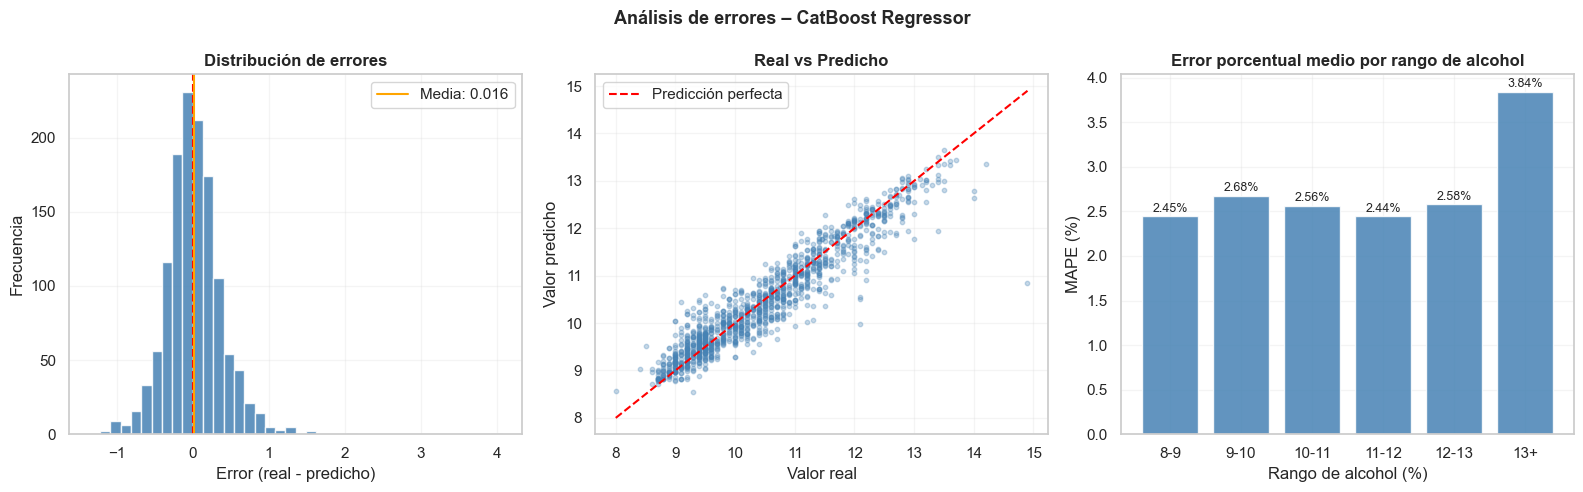


Error máximo:    4.065
Error mínimo:    0.000
Error medio abs: 0.274
% errores < 5%:  86.8%
% errores < 10%: 98.5%


In [40]:
errores = y_test - y_pred_r
errores_pct = (errores / y_test) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de errores – CatBoost Regressor', fontsize=13, fontweight='bold')

# Distribución de errores
axes[0].hist(errores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].axvline(errores.mean(), color='orange', linewidth=1.5, linestyle='-', label=f'Media: {errores.mean():.3f}')
axes[0].set_title('Distribución de errores', fontweight='bold')
axes[0].set_xlabel('Error (real - predicho)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Real vs Predicho
axes[1].scatter(y_test, y_pred_r, alpha=0.3, color='steelblue', s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linewidth=1.5, linestyle='--', label='Predicción perfecta')
axes[1].set_title('Real vs Predicho', fontweight='bold')
axes[1].set_xlabel('Valor real')
axes[1].set_ylabel('Valor predicho')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

# Error porcentual por rango de alcohol
bins = [8, 9, 10, 11, 12, 13, 15]
labels = ['8-9', '9-10', '10-11', '11-12', '12-13', '13+']
rangos = pd.cut(y_test, bins=bins, labels=labels, right=False)
mape_rango = errores_pct.abs().groupby(rangos).mean()

axes[2].bar(mape_rango.index, mape_rango.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_title('Error porcentual medio por rango de alcohol', fontweight='bold')
axes[2].set_xlabel('Rango de alcohol (%)')
axes[2].set_ylabel('MAPE (%)')
axes[2].grid(True, alpha=0.2)
for i, v in enumerate(mape_rango.values):
    axes[2].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nError máximo:    {errores.abs().max():.3f}")
print(f"Error mínimo:    {errores.abs().min():.3f}")
print(f"Error medio abs: {errores.abs().mean():.3f}")
print(f"% errores < 5%:  {(errores_pct.abs() < 5).mean()*100:.1f}%")
print(f"% errores < 10%: {(errores_pct.abs() < 10).mean()*100:.1f}%")

## Evaluación del modelo final – CatBoost Regressor

### Resultados en test

| Métrica | Valor  |
|---------|--------|
| MAPE    | 2.61%  |
| RMSE    | 0.3814 |
| R²      | 0.897  |

### Análisis de errores

**Distribución de errores:**
- Media prácticamente 0 (0.016) → modelo sin sesgo significativo.
- Distribución asimétrica con cola a la derecha → tiende a subestimar ligeramente los valores altos de alcohol.

**Real vs Predicho:**
- Los puntos siguen muy bien la línea de predicción perfecta → excelente ajuste general.
- Algo más de dispersión en valores superiores a 12% → mayor dificultad con vinos muy alcohólicos, que son los menos frecuentes en el dataset.


### Conclusiones generales

- El modelo explica el **89.7% de la varianza** del grado alcohólico → muy buen ajuste.
- El MAPE en test (2.61%) es **mejor que en CV (2.65%)** → no hay overfitting.
- El error es muy contenido y homogéneo en la mayor parte del rango de alcohol.
- El único punto débil son los **vinos muy alcohólicos (>13%)** por falta de muestras representativas.

